In [149]:
import pandas as pd
# install rocket
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sktime.classification.kernel_based import RocketClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore



In [123]:
# load csv TS_NO_OUTLIERS
df = pd.read_csv('TS_NO_OUTLIERS.csv')

In [124]:

# Analisi preliminare del target
print("Distribuzione delle classi nel target 'rating_category':")
print(df['rating_category'].value_counts())
print(f"\nNumero di classi uniche: {df['rating_category'].nunique()}")

# Encoding del target se necessario

# Prepara le features (escludi il target e eventuali colonne non numeriche)
# Time series soslo colonnne con numeri nel nome della colonna
columns_with_numbers = [col for col in df.columns if any(char.isdigit() for char in col)]
print(f"Colonne con numeri: {columns_with_numbers}")

Distribuzione delle classi nel target 'rating_category':
rating_category
2    387
4    361
3    226
1    128
0     10
Name: count, dtype: int64

Numero di classi uniche: 5
Colonne con numeri: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99']


In [159]:
from sktime.classification.deep_learning import InceptionTimeClassifier

inception = InceptionTimeClassifier(
    random_state=42, 
    verbose=True, 
    n_epochs=10,
    batch_size=8    
)

In [160]:
# split train e test
X_train, X_test, y_train, y_test = train_test_split(
    df[columns_with_numbers].values, df['rating_category'].values, test_size=0.2, random_state=42
)
X_train = zscore(X_train, axis=1)
X_test = zscore(X_test, axis=1)
# Fit the InceptionTime model
inception.fit(X_train, y_train)

Model: "model_41"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_42 (InputLayer)          [(None, 100, 1)]     0           []                               
                                                                                                  
 max_pooling1d_246 (MaxPooling1  (None, 100, 1)      0           ['input_42[0][0]']               
 D)                                                                                               
                                                                                                  
 conv1d_1265 (Conv1D)           (None, 100, 32)      1280        ['input_42[0][0]']               
                                                                                                  
 conv1d_1266 (Conv1D)           (None, 100, 32)      640         ['input_42[0][0]']        

InceptionTimeClassifier(batch_size=8, n_epochs=10, random_state=42,
                        verbose=True)

28/28 [==============================] - 1s 33ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.25      0.04      0.07        25
           2       0.44      0.95      0.60        84
           3       0.37      0.14      0.21        49
           4       0.63      0.19      0.29        63

    accuracy                           0.45       223
   macro avg       0.34      0.27      0.23       223
weighted avg       0.45      0.45      0.36       223

Confusion Matrix:
[[ 0  0  2  0  0]
 [ 0  1 24  0  0]
 [ 0  1 80  0  3]
 [ 0  1 37  7  4]
 [ 0  1 38 12 12]]
Accuracy: 0.45


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

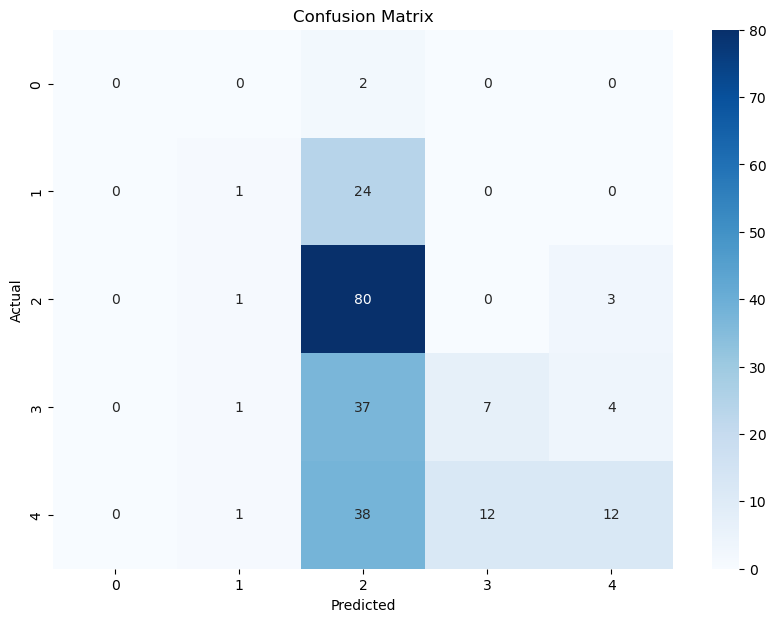

In [161]:
# fit on test
y_pred = inception.predict(X_test)
# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
# CONFIGURAZIONE OTTIMIZZATA INCEPTIONTIME

from sktime.classification.deep_learning import InceptionTimeClassifier
from sklearn.utils.class_weight import compute_class_weight

# Configurazione ottimizzata
inception_optimized = InceptionTimeClassifier(
    # Parametri base
    random_state=42,
    verbose=True,
    
    # Training ottimizzato
    n_epochs=100,           
    batch_size=16,        

    # Architettura ottimizzata
    depth=8,                
    kernel_size=41,         # Kernel size standard
    
    # Regolarizzazione
    use_residual=True,      
    use_bottleneck=True,   
    bottleneck_size=32
)

print("✅ Configurazione ottimizzata creata")

✅ Configurazione ottimizzata creata


In [147]:
inception_optimized.fit(X_train, y_train)

Model: "model_36"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_37 (InputLayer)          [(None, 100, 1)]     0           []                               
                                                                                                  
 max_pooling1d_216 (MaxPooling1  (None, 100, 1)      0           ['input_37[0][0]']               
 D)                                                                                               
                                                                                                  
 conv1d_1111 (Conv1D)           (None, 100, 32)      1312        ['input_37[0][0]']               
                                                                                                  
 conv1d_1112 (Conv1D)           (None, 100, 32)      640         ['input_37[0][0]']        

InceptionTimeClassifier(batch_size=16, depth=8, kernel_size=41, n_epochs=100,
                        random_state=42, verbose=True)

14/14 [==============================] - 0s 10ms/step
Classification Report (Optimized):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00        25
           2       0.50      0.29      0.36        84
           3       0.35      0.31      0.33        49
           4       0.35      0.73      0.47        63

    accuracy                           0.38       223
   macro avg       0.24      0.26      0.23       223
weighted avg       0.36      0.38      0.34       223

Confusion Matrix (Optimized):
[[ 0  0  1  0  1]
 [ 0  0  8  5 12]
 [ 0  1 24 13 46]
 [ 0  0  8 15 26]
 [ 0  0  7 10 46]]
Accuracy (Optimized): 0.38


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

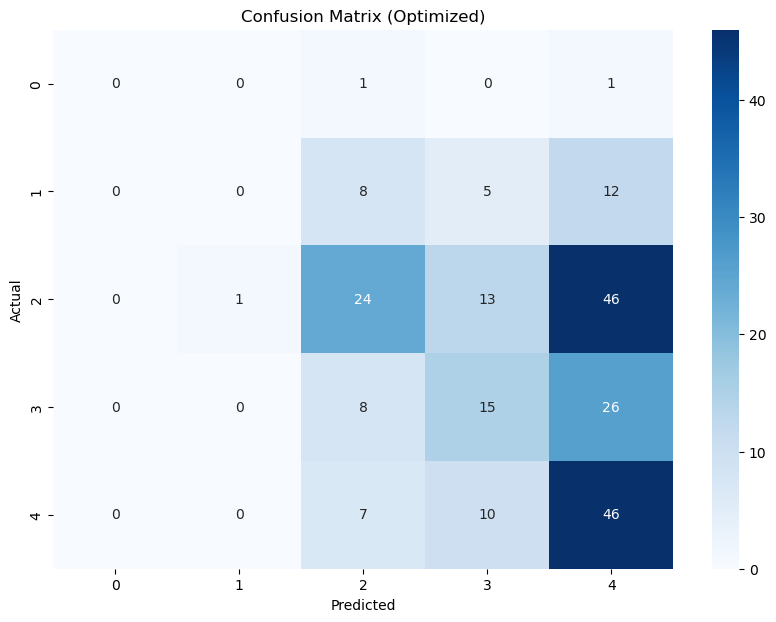

In [148]:
# predict
y_pred_optimized = inception_optimized.predict(X_test)
# Evaluate the optimized model
print("Classification Report (Optimized):")
print(classification_report(y_test, y_pred_optimized))
print("Confusion Matrix (Optimized):")
print(confusion_matrix(y_test, y_pred_optimized))
# Calculate accuracy for optimized model
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"Accuracy (Optimized): {accuracy_optimized:.2f}")
# Plot confusion matrix for optimized model
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred_optimized), annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix (Optimized)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
# Confronto tra i due modelli
